# 12 Nikolov LE Empirical Policy Function

Limited-enforcement (LE) variant of the Nikolov, Schmid, Steri (2021) model, mirroring the TO pipeline in `docs/10_nikolov_to_policy_pipeline.ipynb`: solve the LE LP, simulate a grid-state firm panel (the LE contract is shock-contingent), construct observables, fit degree-2 empirical policy functions, and plot 6 partial-dependence policy slices with 95% CI bands.

The deliverable is the policy-slice figure. **Cost note:** the LE solver enumerates `(n_b * n_p) ** (2 * n_z)` contracts per state, so `n_b` and `n_z` are kept small while `n_k` stays fine. Indirect inference (Section 6) is a disabled scaffold.

In [1]:
from pathlib import Path
import os
import pickle
import sys
import time

SEED = 20260528

PROFILE_NAME = os.environ.get("NIKOLOV_PROFILE", "BASE")  # "SMOKE" or "BASE"
if PROFILE_NAME not in {"SMOKE", "BASE"}:
    raise ValueError("PROFILE_NAME must be 'SMOKE' or 'BASE'.")

SAVE_FIGURES = True
FIG_DPI = 160
# Indirect inference is scaffolded (Section 6) but disabled by default: the LE
# contract enumeration makes one-solve-per-candidate estimation prohibitive.
RUN_INFERENCE = False

OUTPUT_ROOT = Path("outputs/notebooks/12_nikolov_le_policy_pipeline")

# Gentle, limited-liability-feasible calibration (matches docs/09_nikolov_models).
# The Table-2 calibration used for the TO model (docs/10) is INFEASIBLE for the
# limited-liability LE/MH variants: a large downside shock cannot cover capital
# depreciation, so the constraint payment <= resources admits no feasible
# contract. This illustrative calibration keeps the worst shock survivable.
PARAM_KWARGS = dict(
    tau=0.20,
    alpha=0.75,
    f=0.70,
    delta=0.15,
    psi=0.15,
    r=0.04,
    kappa=0.50,
    eta_bar=0.30,
    xi=0.60,
    theta=0.70,
    lambda_diversion=0.04,
)

AR1_KWARGS = dict(rho=0.80, sigma=0.30, mu=0.0, z_sd_mult=3.0)

# LP cost is (n_b * n_p) ** (2 * n_z) shock-contingent contracts PER state,
# so n_b and n_z must stay tiny; n_k is only quadratic and stays affordable.
# n_p is set equal to n_b so the payment grid aligns with r * b-grid:
# the constant "rollover" contract (b_next=b, pay the interest) then lands
# exactly on the grid, which is what makes the exact break-even/promise-keeping
# constraint satisfiable. BASE keeps a fine n_k=21; SMOKE is 5 x 5 x 2.
GRID_KNOBS = dict(k_low_mult=0.50, k_high_mult=1.50, debt_pledge_fraction=0.35)
GRID_BASE = dict(n_k=15, n_b=7, n_p=7, n_z=5)
GRID_SMOKE = dict(n_k=5, n_b=3, n_p=3, n_z=2)
GRID = GRID_BASE if PROFILE_NAME == "BASE" else GRID_SMOKE

SIMULATION_KWARGS = dict(
    n_firms=1000 if PROFILE_NAME == "BASE" else 200,
    horizon=50 if PROFILE_NAME == "BASE" else 8,
    burn_in=20 if PROFILE_NAME == "BASE" else 4,
    seed=SEED,
)

POLICY_X_COLS = ["log_k", "profitability", "leverage"]
POLICY_Y_COLS = ["investment_rate", "future_leverage", "payout_rate"]
POLICY_DEGREE = 2

REPO_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "src" / "v2").exists():
        REPO_ROOT = candidate
        break
if REPO_ROOT is None:
    import importlib.util
    spec = importlib.util.find_spec("src.v2")
    if spec is not None and spec.origin is not None:
        REPO_ROOT = Path(spec.origin).resolve().parents[2]
if REPO_ROOT is None:
    raise RuntimeError("Could not find repo root containing src/v2.")
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

OUTPUT_DIR = (OUTPUT_ROOT if OUTPUT_ROOT.is_absolute() else REPO_ROOT / OUTPUT_ROOT) / PROFILE_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(OUTPUT_DIR / ".mplconfig"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

SOLUTION_PATH = OUTPUT_DIR / "le_solution.pkl"
PANEL_PATH = OUTPUT_DIR / "le_simulated_panel.csv"
COEFFICIENT_PATH = OUTPUT_DIR / "empirical_policy_coefficients.csv"
FIT_SUMMARY_PATH = OUTPUT_DIR / "empirical_policy_fit_summary.csv"
FIGURE_PATH = OUTPUT_DIR / "le_empirical_policy_slices.png"

contracts = (GRID["n_b"] * GRID["n_p"]) ** (2 * GRID["n_z"])
print(f"profile={PROFILE_NAME} seed={SEED} model=LE")
print(f"output={OUTPUT_DIR.relative_to(REPO_ROOT)}")
print(f"grid={GRID} -> contracts/state={contracts:,}")
print(f"simulation={SIMULATION_KWARGS}")


profile=BASE seed=20260528 model=LE
output=outputs/notebooks/12_nikolov_le_policy_pipeline/BASE
grid={'n_k': 15, 'n_b': 7, 'n_p': 7, 'n_z': 5} -> contracts/state=79,792,266,297,612,001
simulation={'n_firms': 1000, 'horizon': 50, 'burn_in': 20, 'seed': 20260528}


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.v2.environments.nikolov import (
    NikolovGridConfig,
    NikolovParams,
    ar1_z_bounds,
    calibrated_k_bounds,
    conservative_debt_bound,
)
from src.v2.estimation.empirical_policy import (
    EmpiricalPolicyConfig,
    empirical_policy_coefficients,
    fit_empirical_policy,
    partial_dependence_slices,
)
from src.v2.simulation.nikolov_le import (
    NikolovLESimulationConfig,
    construct_le_observables,
    simulate_nikolov_le_panel,
)
from src.v2.solvers.nikolov_le import solve_nikolov_le

plt.rcParams.update({
    "figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
})

params = NikolovParams(**PARAM_KWARGS)
# Raw (unstandardized) degree-2 polynomial so coefficients are comparable across
# panels and between data and simulation (same convention as the TO notebook).
AUX_CONFIG = EmpiricalPolicyConfig(degree=POLICY_DEGREE, standardize=False)


def build_model_config():
    """LE grid from nb09's proven-feasible recipe (collateral-aware debt bound)."""
    z_bar = float(np.exp(AR1_KWARGS["mu"]))
    z_bounds = ar1_z_bounds(
        rho=AR1_KWARGS["rho"], sigma=AR1_KWARGS["sigma"],
        mu=AR1_KWARGS["mu"], z_sd_mult=AR1_KWARGS["z_sd_mult"],
    )
    k_bounds = calibrated_k_bounds(
        params, low_mult=GRID_KNOBS["k_low_mult"],
        high_mult=GRID_KNOBS["k_high_mult"], z_bar=z_bar,
    )
    b_max = conservative_debt_bound(
        params, k_low=k_bounds[0], pledge_fraction=GRID_KNOBS["debt_pledge_fraction"],
    )
    return NikolovGridConfig(
        k_bounds=k_bounds,
        b_bounds=(0.0, b_max),
        p_bounds=(0.0, params.r * b_max),
        z_bounds=z_bounds,
        n_k=GRID["n_k"], n_b=GRID["n_b"], n_p=GRID["n_p"], n_z=GRID["n_z"],
        z_transition=None,
        z_rho=AR1_KWARGS["rho"], z_sigma=AR1_KWARGS["sigma"], z_mu=AR1_KWARGS["mu"],
    )


def solve_model():
    return solve_nikolov_le(build_model_config(), params)


simulate_panel = simulate_nikolov_le_panel
construct_observables = construct_le_observables
SimulationConfig = NikolovLESimulationConfig


def save_figure(fig, path):
    if SAVE_FIGURES:
        fig.savefig(path, dpi=FIG_DPI, bbox_inches="tight")
        print(f"saved {path.relative_to(REPO_ROOT)}")


def finite_nondefault(df):
    cols = POLICY_X_COLS + POLICY_Y_COLS
    return df.loc[
        (~df["default"].astype(bool))
        & np.isfinite(df[cols].to_numpy(dtype=np.float64)).all(axis=1)
    ].copy()


Matplotlib is building the font cache; this may take a moment.
/Users/wangzhaoxuan/Desktop/JPM-TSRL/DL_corp_finance/.venv/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## 1. Solve LE policy

In [3]:
config = build_model_config()
print(f"k_bounds={tuple(round(x, 3) for x in config.k_bounds)}")
print(f"b_bounds={tuple(round(x, 3) for x in config.b_bounds)}  p_bounds={tuple(round(x, 4) for x in config.p_bounds)}")
print(f"z_bounds={tuple(round(x, 3) for x in config.z_bounds)}")
start = time.perf_counter()
result = solve_model()
print(f"solved in {time.perf_counter() - start:.1f}s")
diag = result["diagnostics"]
print(f"feasible actions total={diag['total_feasible_actions']:,}, "
      f"states with none={diag['states_with_no_feasible_actions']}")
print(f"max LP violation={diag['max_lp_violation']:.2e}")
with SOLUTION_PATH.open("wb") as fh:
    pickle.dump({"config": config, "params": params, "result": result}, fh)
print(f"saved {SOLUTION_PATH.relative_to(REPO_ROOT)}")


k_bounds=(98.877, 296.631)
b_bounds=(0.0, 19.799)  p_bounds=(0.0, 0.792)
z_bounds=(0.223, 4.482)


KeyboardInterrupt: 

## 2. Simulate model panel

In [ ]:
sim_cfg = SimulationConfig(**SIMULATION_KWARGS)
panel = simulate_panel(result, params, sim_cfg)
panel.to_csv(PANEL_PATH, index=False)
print(f"panel rows={len(panel):,}, firms={panel['firm_id'].nunique()}")
print(f"saved {PANEL_PATH.relative_to(REPO_ROOT)}")


panel rows=50,000, firms=1000
saved outputs/notebooks/12_nikolov_le_policy_pipeline/BASE/le_simulated_panel.csv


## 3. Construct observables

In [ ]:
observables_all = construct_observables(panel)
observables = finite_nondefault(observables_all)
fit_sample = observables
print(f"observations: all={len(observables_all):,}, finite/non-default={len(observables):,}")
print(observables[POLICY_X_COLS + POLICY_Y_COLS].describe().round(4).to_string())


observations: all=50,000, finite/non-default=50,000
            log_k  profitability    leverage  investment_rate  future_leverage  payout_rate
count  50000.0000     50000.0000  50000.0000          50000.0       50000.0000   50000.0000
mean       2.8134         0.2503      0.0534              0.1           0.0534       0.1181
std        0.0000         0.0335      0.0503              0.0           0.0503       0.0269
min        2.8134         0.1946      0.0000              0.1           0.0000       0.0716
25%        2.8134         0.2499      0.0000              0.1           0.0000       0.1163
50%        2.8134         0.2499      0.1010              0.1           0.1010       0.1182
75%        2.8134         0.2523      0.1010              0.1           0.1010       0.1215
max        2.8134         0.3077      0.1010              0.1           0.1010       0.1662


## 4. Fit empirical policy functions

In [ ]:
fit = fit_empirical_policy(observables, POLICY_X_COLS, POLICY_Y_COLS, AUX_CONFIG)
coefficients = empirical_policy_coefficients(fit)
coefficients.to_csv(COEFFICIENT_PATH, index=False)
print(f"fit observations={fit.n_observations:,}, features={len(fit.feature_names)}")
fit_summary = pd.DataFrame([
    dict(
        outcome=y_col,
        r2=outcome.r2,
        rmse=float(np.sqrt(np.mean(np.square(outcome.residuals)))),
        sigma2=outcome.sigma2,
        dof=outcome.dof,
        n_observations=fit.n_observations,
    )
    for y_col, outcome in fit.outcomes.items()
])
fit_summary.to_csv(FIT_SUMMARY_PATH, index=False)
print(fit_summary.round(4).to_string(index=False))
top = coefficients.reindex(
    coefficients["t_stat"].abs().sort_values(ascending=False).index
).head(12)
print("\ntop terms by |t|:")
print(top[["outcome", "feature", "coefficient", "std_error", "t_stat"]].round(4).to_string(index=False))
print(f"\nsaved coefficients: {COEFFICIENT_PATH.relative_to(REPO_ROOT)}")
print(f"saved fit summary: {FIT_SUMMARY_PATH.relative_to(REPO_ROOT)}")


fit observations=50,000, features=10
        outcome     r2   rmse  sigma2   dof  n_observations
investment_rate 1.0000 0.0000  0.0000 49990           50000
future_leverage 0.9996 0.0010  0.0000 49990           50000
    payout_rate 0.5134 0.0187  0.0004 49990           50000

top terms by |t|:
        outcome                feature  coefficient  std_error        t_stat
investment_rate                log_k^2       0.0111     0.0000  5.197234e+08
investment_rate                      1       0.0014     0.0000  3.998100e+08
investment_rate                  log_k       0.0039     0.0000  6.432473e+07
future_leverage             leverage^2       0.9051     0.0327  2.771830e+01
    payout_rate        profitability^2      -1.1007     0.0568 -1.938920e+01
future_leverage         log_k leverage       0.2867     0.0261  1.099850e+01
    payout_rate             leverage^2      -1.3267     0.5960 -2.226000e+00
future_leverage               leverage       0.1019     0.0733  1.390700e+00
future_leve

## 5. Policy-slice figure

Each panel plots a **partial-dependence** curve (red): the fitted policy averaged over the observed distribution of the other states while one state is swept over its 2-98% range, with a closed-form 95% CI band. Black dots are the binned conditional mean of the simulated panel; blue points are the raw marginal cloud. The leverage axis is coarse because the contract grid must stay small.

saved outputs/notebooks/12_nikolov_le_policy_pipeline/BASE/le_empirical_policy_slices.png


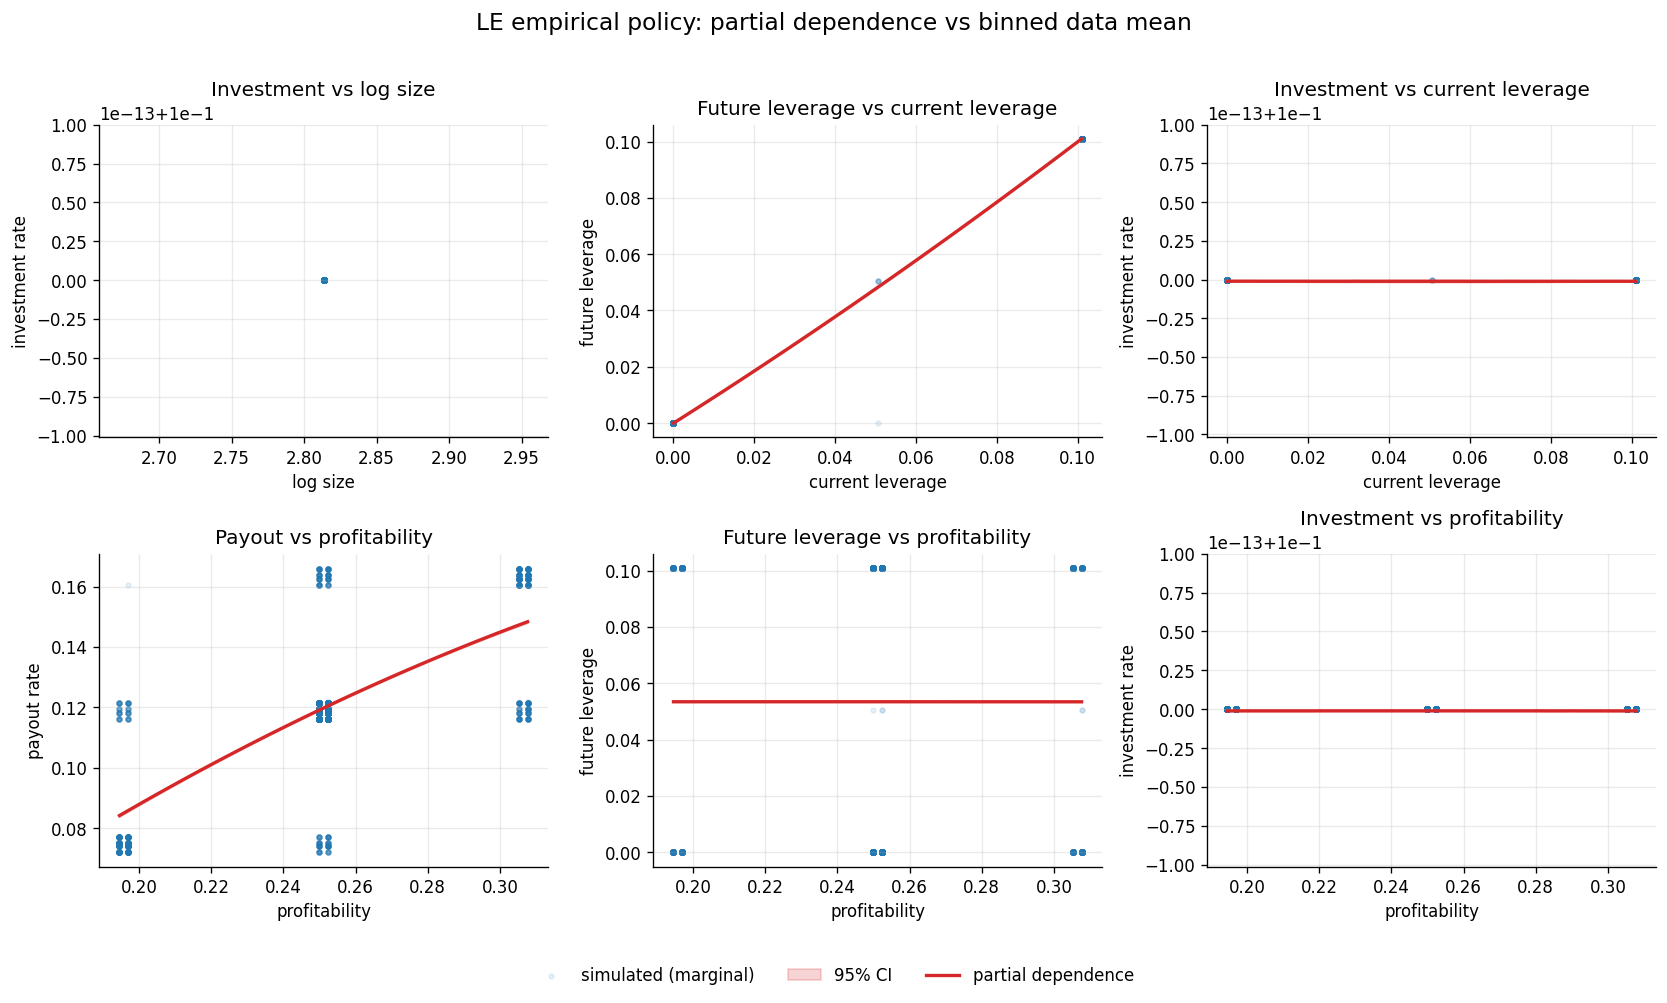

In [ ]:
slice_predictions = partial_dependence_slices(
    fit, observables, POLICY_X_COLS,
    grid_size=100, ci_level=0.95, quantile_range=(0.02, 0.98),
)
plot_sample = fit_sample.sample(
    n=min(2500, len(fit_sample)), random_state=SEED,
) if len(fit_sample) else fit_sample

state_labels = {
    "log_k": "log size",
    "profitability": "profitability",
    "leverage": "current leverage",
}
action_labels = {
    "investment_rate": "investment rate",
    "future_leverage": "future leverage",
    "payout_rate": "payout rate",
}
comparative_statics = [
    ("investment_rate", "log_k", "Investment vs log size"),
    ("future_leverage", "leverage", "Future leverage vs current leverage"),
    ("investment_rate", "leverage", "Investment vs current leverage"),
    ("payout_rate", "profitability", "Payout vs profitability"),
    ("future_leverage", "profitability", "Future leverage vs profitability"),
    ("investment_rate", "profitability", "Investment vs profitability"),
]


def dedup_legend(axes):
    handles, labels = [], []
    for ax in np.atleast_1d(axes).ravel():
        for handle, label in zip(*ax.get_legend_handles_labels()):
            if label not in labels:
                handles.append(handle)
                labels.append(label)
    return handles, labels


fig, axes = plt.subplots(2, 3, figsize=(14, 8.4))
for ax, (y_col, x_col, title) in zip(axes.ravel(), comparative_statics):
    ax.scatter(
        plot_sample[x_col], plot_sample[y_col],
        s=8, alpha=0.10, color="tab:blue", label="simulated (marginal)",
    )
    n_bins = min(20, int(fit_sample[x_col].nunique()))
    if n_bins >= 2:
        try:
            bins = pd.qcut(fit_sample[x_col], q=n_bins, duplicates="drop")
            means = fit_sample.groupby(bins, observed=True)[[x_col, y_col]].mean().sort_values(x_col)
            ax.plot(
                means[x_col], means[y_col],
                marker="o", linestyle="", color="black", markersize=3.5,
                label="binned data mean",
            )
        except ValueError:
            pass
    pred = slice_predictions[x_col]
    ax.fill_between(
        pred[x_col], pred[f"{y_col}_lower"], pred[f"{y_col}_upper"],
        color="tab:red", alpha=0.20, label="95% CI",
    )
    ax.plot(pred[x_col], pred[y_col], color="tab:red", linewidth=2, label="partial dependence")
    ax.set_title(title)
    ax.set_xlabel(state_labels[x_col])
    ax.set_ylabel(action_labels[y_col])

handles, labels = dedup_legend(axes)
fig.suptitle("LE empirical policy: partial dependence vs binned data mean", fontsize=14)
fig.tight_layout(rect=(0, 0.06, 1, 0.97))
fig.legend(
    handles, labels, loc="lower center", ncol=len(labels),
    bbox_to_anchor=(0.5, 0.0), frameon=False,
)
save_figure(fig, FIGURE_PATH)
plt.show()


## 6. Indirect inference (disabled scaffold)

Indirect inference is intentionally **disabled by default** for this model (`RUN_INFERENCE = False`). Only the TO model has a wired-up II loop; the LE contract enumeration would require one expensive solve per candidate parameter vector.

In [ ]:
if RUN_INFERENCE:
    raise NotImplementedError(
        "Indirect inference for the LE model is not wired up. Only the TO "
        "model has an II loop (docs/10_nikolov_to_policy_pipeline.ipynb). The LE "
        "solver enumerates (n_b * n_p) ** (2 * n_z) shock-contingent contracts "
        "per state, so one solve per candidate makes a full estimation prohibitive. "
        "This section is intentionally a disabled scaffold."
    )
print("indirect inference disabled (RUN_INFERENCE=False); the policy-slice figure is the deliverable.")


indirect inference disabled (RUN_INFERENCE=False); the policy-slice figure is the deliverable.


## Output summary

In [ ]:
print("artefacts:")
for p in [SOLUTION_PATH, PANEL_PATH, COEFFICIENT_PATH, FIT_SUMMARY_PATH, FIGURE_PATH]:
    print(f"  {p.relative_to(REPO_ROOT)}  exists={p.exists()}")


artefacts:
  outputs/notebooks/12_nikolov_le_policy_pipeline/BASE/le_solution.pkl  exists=True
  outputs/notebooks/12_nikolov_le_policy_pipeline/BASE/le_simulated_panel.csv  exists=True
  outputs/notebooks/12_nikolov_le_policy_pipeline/BASE/empirical_policy_coefficients.csv  exists=True
  outputs/notebooks/12_nikolov_le_policy_pipeline/BASE/empirical_policy_fit_summary.csv  exists=True
  outputs/notebooks/12_nikolov_le_policy_pipeline/BASE/le_empirical_policy_slices.png  exists=True
